In [1]:
# %load_ext autoreload
# %autoreload 2

# The Barchart settle fetcher underneath `sfr_cvx_adj` calls `asyncio.run()`, and
# a Jupyter kernel already owns a running loop -- without this the whole notebook
# dies on "asyncio.run() cannot be called from a running event loop". This is why
# eod_linear_rates.ipynb opens the same way.
import nest_asyncio
nest_asyncio.apply()

import plotly.io as pio
pio.renderers.default = "plotly_mimetype+notebook_connected"

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
plt.style.use("ggplot")
pylab.rcParams.update({
    "legend.fontsize": "medium", "figure.figsize": (18, 6),
    "axes.labelsize": "medium", "axes.titlesize": "medium",
    "xtick.labelsize": "medium", "ytick.labelsize": "medium",
})

import datetime
import os
import sys

import numpy as np
import pandas as pd
import pytz

os.environ.setdefault("ARBS_SUPABASE_ENABLED", "0")
NYC_tz = pytz.timezone("America/New_York")
sys.path.append("../../")

from RVUtils.plt_timeseries import make_secondary_axis_plot

# SFR convexity adjustment

`CA = pack_rate − matched_swap_rate`, in basis points, for each of the five
pack colours Citi prints. The pack rate is the average of four consecutive SR3
settles; the matched swap is the forward swap covering the same window,
**quarterly/quarterly** — Citi specifies that verbatim, and the `usd_irs` spec
quotes annual fixed, which is a 4.6–5.9 bp error on a quantity that is itself
1–20 bp.

Two things to know before reading any number here:

* **The adjustment grows with rank.** Whites sit ~0.3 months out and Golds
  ~4 years; `CA = ½·σ²·mean(T1²)`, so it is a variance quantity and the deeper
  colour should always carry more. That monotonicity is the cheapest sanity
  check available on this series.
* **Deep colours were unavailable until recently.** Blues had 49 usable dates
  in 2023 and Golds had none at all in 2026 before the SR3 settle warm; they
  now carry ~250 dates a year.

In [15]:
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from TB.IRSwapsTB import IRSwapsTB
from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP, _alias_to_cusip
from MDP.IRSwaptions.IRSwaptionMDP import IRSwaptionMDP
from TB.IRSwaptionsTB import IRSwaptionsTB
from TB.FixedRateBondsTB import FixedRateBondsTB
from Query.Unified.UnifiedQuery import UnifiedQuery
from Query.Unified.registry import UnifiedStructure, UnifiedValue
from TB.TimeseriesBuilder import TimeseriesBuilder

# curve_mdp = IRSwapsMDP(source="CITIVELO_EXCEL")
curve_mdp = IRSwapsMDP(source="citivelo_excel_rl")
usts_mdp = FixedRateBondsMDP(source="USTS_FEDINVEST_WSJ_LIVE-RL")
vol_mdp = IRSwaptionMDP(
    source="CITIVELO-RL",
    curve_source="citivelo_excel_rl",
    request_defaults={"verify": False},
)

start = datetime.date(2024, 8, 21)
end = datetime.date(2026, 8, 21)

In [16]:
COLOURS = ["WHITES", "REDS", "GREENS", "BLUES", "GOLDS"]
ca_df = IRSwapsTB(curve_mdp, show_tqdm=True).sfr_cvx_adj(COLOURS, start, end)
ca_df


,USD-SOFR-1D WHITES PACKS CVX_ADJ,USD-SOFR-1D REDS PACKS CVX_ADJ,USD-SOFR-1D GREENS PACKS CVX_ADJ,USD-SOFR-1D BLUES PACKS CVX_ADJ,USD-SOFR-1D GOLDS PACKS CVX_ADJ
Date,,,,,
2024-08-21,-0.908762,1.601123,4.141197,9.154521,14.192491
2024-08-22,0.010900,1.538441,4.175960,10.223159,14.770798
2024-08-23,0.702285,0.687271,4.455375,9.045750,12.899271
2024-08-26,-0.754748,1.551013,4.161602,9.001514,11.476781
2024-08-27,-0.811759,1.523673,4.103382,8.315700,10.851569
...,...,...,...,...,...
2026-08-17,0.066234,0.562448,2.519989,5.684035,8.738245
2026-08-18,0.186018,0.787803,2.620597,6.171205,9.484143
2026-08-19,1.780621,-0.782571,2.623165,5.997563,9.439120


In [17]:
df = TimeseriesBuilder().get_timeseries(
    start=start,
    end=end,
    queries=[
        UnifiedQuery(
            curve="USD-SOFR-1D",
            tenor="IMM_1x2y/IMM_1x5y/IMM_1x10y",
            value=UnifiedValue.IRS_RATE,
        ),
		UnifiedQuery(
            curve="USD-SOFR-1D",
            tenor="IMM_2x2y/IMM_2x5y/IMM_2x10y",
            value=UnifiedValue.IRS_RATE,
        ),
		UnifiedQuery(
            curve="USD-SOFR-1D",
            tenor="IMM_1x5y/IMM_1x10y/IMM_1x30y",
            value=UnifiedValue.IRS_RATE,
        ),
		UnifiedQuery(
            curve="USD-SOFR-1D",
            tenor="IMM_2x5y/IMM_2x10y/IMM_2x30y",
            value=UnifiedValue.IRS_RATE,
        ),
        UnifiedQuery(
            curve="USD-SOFR-1D",
            tenor="10y10y/20y10y",
            value=UnifiedValue.IRS_RATE,
        ),
		UnifiedQuery(
            curve="USD-SOFR-1D",
            tenor="10y10y/15y10y",
            value=UnifiedValue.IRS_RATE,
        ),
		# UnifiedQuery(
        #     curve="USD-SOFR-1D",
        #     tenor="IMM_1x5y/IMM_1x10y/IMM_1x30y",
        #     value=UnifiedValue.IRS_RATE,
        # ),
		# UnifiedQuery(
		# 	curve="USD-SOFR-1D",
		# 	selector={"shorthand":  "1Yx1Y", "strike": "ATMF"},
		# 	structure=UnifiedStructure.IRSWAPTION_STRADDLE,
		# 	value=UnifiedValue.IRSWAPTION_NVOL,
		# ),
		UnifiedQuery(
			curve="USD-SOFR-1D",
			selector={"shorthand":  "2Yx1Y", "strike": "ATMF"},
			structure=UnifiedStructure.IRSWAPTION_STRADDLE,
			value=UnifiedValue.IRSWAPTION_NVOL,
		),
		UnifiedQuery(
			curve="USD-SOFR-1D",
			selector={"shorthand":  "3Yx1Y", "strike": "ATMF"},
			structure=UnifiedStructure.IRSWAPTION_STRADDLE,
			value=UnifiedValue.IRSWAPTION_NVOL,
		),
		UnifiedQuery(
			curve="USD-SOFR-1D",
			selector={"shorthand":  "4Yx1Y", "strike": "ATMF"},
			structure=UnifiedStructure.IRSWAPTION_STRADDLE,
			value=UnifiedValue.IRSWAPTION_NVOL,
		),
    ],
    n_jobs=12,
    routers={
        "IRS": IRSwapsTB(curve_mdp, show_tqdm=True),
        "FRB": FixedRateBondsTB(usts_mdp, show_tqdm=True),
        "IRSWAPTION":  IRSwaptionsTB(vol_mdp, show_tqdm=True),
    },
)
df

PRICING IRSWAPTIONS.: 0it [00:00, ?it/s]


,USD-SOFR-1D 10y10y/15y10y CURVE RATE,USD-SOFR-1D 10y10y/20y10y CURVE RATE,USD-SOFR-1D IMM_1x2y/IMM_1x5y/IMM_1x10y FLY RATE,USD-SOFR-1D IMM_1x5y/IMM_1x10y/IMM_1x30y FLY RATE,USD-SOFR-1D IMM_2x2y/IMM_2x5y/IMM_2x10y FLY RATE,USD-SOFR-1D IMM_2x5y/IMM_2x10y/IMM_2x30y FLY RATE,USD-SOFR-1D 2Yx1Y STRADDLE BUY ATMF NVOL,USD-SOFR-1D 3Yx1Y STRADDLE BUY ATMF NVOL,USD-SOFR-1D 4Yx1Y STRADDLE BUY ATMF NVOL
Date,,,,,,,,,
2024-08-21,-30.502802,-70.621113,-32.645677,10.119531,-22.453867,13.398118,115.6330,108.8600,106.0890
2024-08-22,-30.632591,-71.833287,-33.261137,9.903835,-23.370100,13.164255,113.9930,108.3350,106.0570
2024-08-23,-30.375356,-71.571499,-34.152094,9.942204,-23.752104,13.248485,112.9890,107.3200,104.7250
2024-08-26,-30.207658,-73.305532,-34.127125,9.052253,-23.684767,12.384498,112.0970,106.8520,104.4220
2024-08-27,-30.501670,-72.800311,-33.807091,10.509987,-23.134901,13.814555,112.3370,107.1140,104.7490
...,...,...,...,...,...,...,...,...,...
2026-08-17,-15.741162,-55.331035,-14.627293,-5.143916,-15.215224,-3.306006,95.6162,94.1809,93.0171
2026-08-18,-15.847600,-55.446459,-14.627435,-5.105314,-15.209285,-3.282329,95.5727,94.4038,93.3033
2026-08-19,-15.365212,-55.387122,-13.650194,-5.701558,-14.570251,-3.922289,94.5382,93.4259,92.3177


In [23]:
plot, fig, ax, ax2, legend = make_secondary_axis_plot(
    engine="plotly", 
	# ylabel_left="convexity adjustment, bp",
    # title="SFR convexity adjustment by pack colour"
)

plot(ca_df["USD-SOFR-1D GREENS PACKS CVX_ADJ"].dropna(), which="left")
plot(ca_df["USD-SOFR-1D BLUES PACKS CVX_ADJ"].dropna(), which="left")
plot(ca_df["USD-SOFR-1D GOLDS PACKS CVX_ADJ"].dropna(), which="left")

# plot(df["USD-SOFR-1D 3Yx1Y STRADDLE BUY ATMF NVOL"].dropna(), which="right")
# plot(df["USD-SOFR-1D 3Yx1Y STRADDLE BUY ATMF NVOL"].dropna(), which="right")
# plot(df["USD-SOFR-1D IMM_1x2y/IMM_1x5y/IMM_1x10y FLY RATE"].dropna(), which="right")
# plot(df["USD-SOFR-1D IMM_2x2y/IMM_2x5y/IMM_2x10y FLY RATE"].dropna(), which="right")
# plot(df["USD-SOFR-1D IMM_1x5y/IMM_1x10y/IMM_1x30y FLY RATE"].dropna(), which="right")
plot(df["USD-SOFR-1D 10y10y/15y10y CURVE RATE"].dropna(), which="right")
legend(show_date=True)

                                   OLS Regression Results                                  
Dep. Variable:     USD-SOFR-1D BLUES PACKS CVX_ADJ   R-squared:                       0.580
Model:                                         OLS   Adj. R-squared:                  0.579
Method:                              Least Squares   F-statistic:                     687.8
Date:                             Mon, 24 Aug 2026   Prob (F-statistic):           7.04e-96
Time:                                     16:32:20   Log-Likelihood:                -702.60
No. Observations:                              500   AIC:                             1409.
Df Residuals:                                  498   BIC:                             1418.
Df Model:                                        1                                         
Covariance Type:                         nonrobust                                         
                                           coef    std err          t      P>|t|

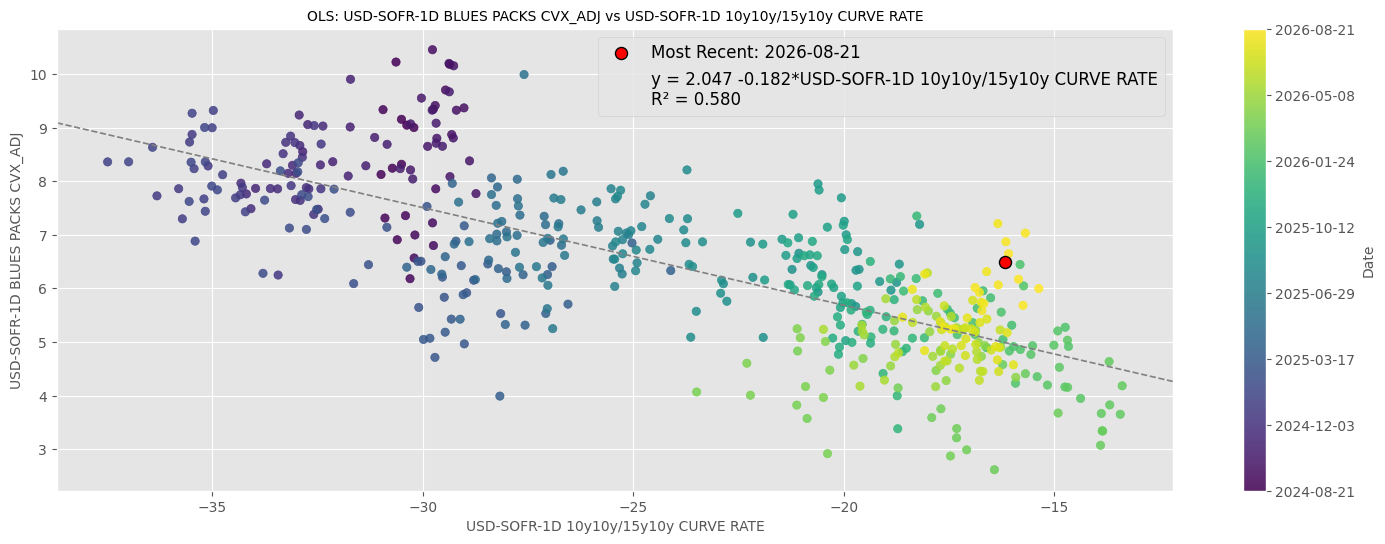

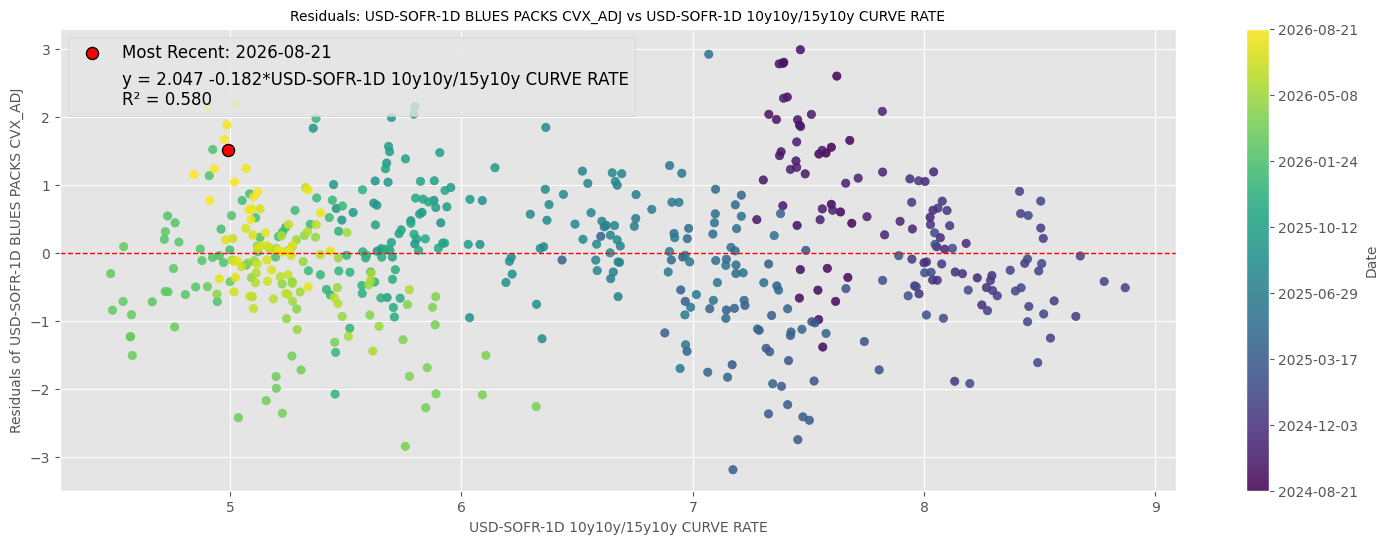

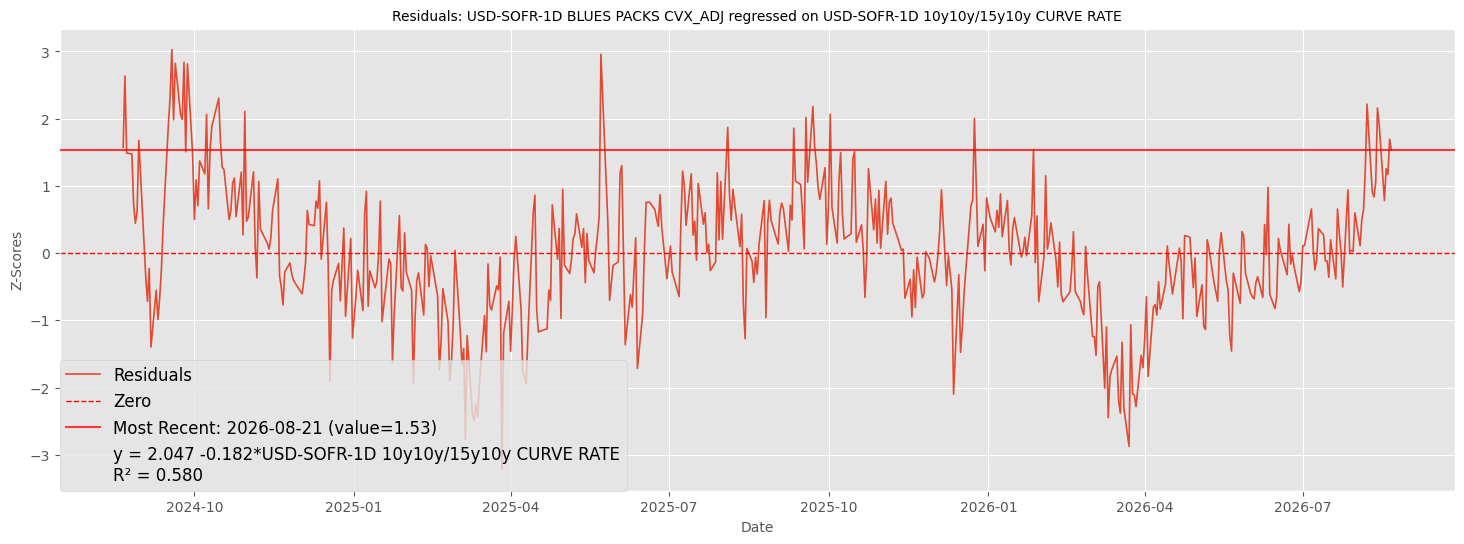

In [22]:
from RVUtils.regression import make_linear_regression_builder

regression_df = pd.merge(ca_df, df, left_index=True, right_index=True) 

add_indep_var, fit, plot_actual_vs_predicted, plot_residuals_vs_predicted, plot_residuals_timeseries, get_data = make_linear_regression_builder(
    df=regression_df,
    y_col="USD-SOFR-1D BLUES PACKS CVX_ADJ",
    date_color_bar=True,
	# on_diff=True
)
# add_indep_var("USD-SOFR-1D IMM_1x2y/IMM_1x5y/IMM_1x10y FLY RATE")
# add_indep_var("USD-SOFR-1D IMM_1x5y/IMM_1x10y/IMM_1x30y FLY RATE")
add_indep_var("USD-SOFR-1D 10y10y/15y10y CURVE RATE")
res = fit(model="OLS", verbose=True)
plot_actual_vs_predicted()
plot_residuals_vs_predicted()
# plot_residuals_timeseries(plot_zscores=True, plot_zero=True, stds=[1, 2])
plot_residuals_timeseries(plot_zscores=True, plot_zero=True, ou_bands=False)

## The current term structure

In [6]:
latest = ca.dropna(how="all").iloc[-1]
asof = ca.dropna(how="all").index[-1]
print(f"as of {asof.date()}")
print(latest.reindex(COLOURS).round(3).to_string())

import plotly.graph_objects as go
_c = latest.reindex(COLOURS).dropna()
f2 = go.Figure(go.Bar(x=_c.index, y=_c.to_numpy(),
                      text=[f"{v:.2f}" for v in _c], textposition="outside"))
f2.update_layout(title=f"SFR convexity adjustment by colour, {asof.date()}",
                 yaxis_title="bp", height=380)
f2.show()

as of 2026-08-20
WHITES    0.350
REDS      0.560
GREENS    2.624
BLUES     6.648
GOLDS     9.934


## Against the 2s5s10s fly

Citi's Figure 9 argues the adjustment is directional with the 2s5s10s swap
fly, and therefore hedgeable with it. On 2021–2026 SOFR that relationship did
**not** reproduce — hedge R² 0.000–0.010 with a sign-flipping beta — so this
panel is here to be looked at rather than relied on.

In [7]:
from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapStructure import IRSwapStructure
from Query.IRSwaps.IRSwapValue import IRSwapValue

try:
    # The slash form is what the query layer auto-detects as a FLY; passing
    # `structure_kwargs={"tenors": [...]}` raises "FLY requires all three leg
    # tenors". Construction is inside the try because that is where it raises.
    fly_q = IRSwapQuery(curve="USD-SOFR-1D", tenor="2Y/5Y/10Y",
                        value=IRSwapValue.RATE, structure_kwargs={"bpv": 1.0})
    fly = tb.get_timeseries(start=start, end=end, queries=[fly_q], n_jobs=8)
    fly.columns = ["2s5s10s fly"]
    print(fly.tail(3).to_string())
except Exception as exc:                                     # noqa: BLE001
    fly = pd.DataFrame()
    print(f"fly unavailable: {type(exc).__name__}: {exc}")

SUCCESS: `func_tol` reached after 6 iterations (levenberg_marquardt), `f_val`: 3.163917978563504e-13, `time`: 0.1535s



PRICING USD-SOFR-1D IRSWAPS [workers=8]...:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\chris\anaconda3\envs\stir\Lib\site-packages\rateslib\data\fixings.py:3426: RuntimeWarning:

invalid value encountered in divide


                                                                                 

            2s5s10s fly
Date                   
2026-08-18      -14.241
2026-08-19      -13.179
2026-08-20      -12.036


In [8]:
if not fly.empty:
    j = ca.join(fly, how="inner").dropna(subset=["2s5s10s fly"])
    plot, fig3, ax, ax2, legend = make_secondary_axis_plot(
        engine="plotly", ylabel_left="CA, bp", ylabel_right="fly, bp",
        title="Greens / Blues convexity adjustment vs the 2s5s10s fly")
    for c in ("GREENS", "BLUES"):
        if c in j.columns and j[c].notna().any():
            plot(j[c].dropna(), which="left", label=c)
    plot(j["2s5s10s fly"].dropna(), which="right", label="2s5s10s fly")
    legend(show_date=True)
    fig3.show()

    corr = j[[c for c in COLOURS if c in j.columns]].corrwith(j["2s5s10s fly"])
    print("\ncorrelation of LEVELS with the fly:")
    print(corr.round(3).to_string())
    dcorr = j.diff().dropna()
    print("\ncorrelation of daily CHANGES with the fly (the one that matters):")
    print(dcorr[[c for c in COLOURS if c in j.columns]]
          .corrwith(dcorr["2s5s10s fly"]).round(3).to_string())
else:
    print("skipped: no fly series")


correlation of LEVELS with the fly:
WHITES    0.092
REDS      0.126
GREENS    0.375
BLUES     0.623
GOLDS     0.528

correlation of daily CHANGES with the fly (the one that matters):
WHITES    0.026
REDS     -0.028
GREENS   -0.014
BLUES    -0.096
GOLDS    -0.095


In [9]:
tb.close()
print("done")

done
